# Peramalan Harga Saham INDF - Model Tunggal BiLSTM
**Model tunggal BiLSTM (tanpa CNN) untuk perbandingan dengan Hybrid CNN-BiLSTM**

Grid parameter:
- n_units         : [16, 32, 64]
- n_bilstm_layers : [1, 2]
- dropout_rate    : [0.1, 0.2, 0.3]
- batch_size      : [16, 32, 64]
- Total: 3 x 2 x 3 x 3 = 54 kombinasi x 3 skenario = 162 run


## CELL 1 — Pra-Pemrosesan Data

## CELL 3 — Load Data & Fungsi Windowing

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model BiLSTM (Tunggal)


In [4]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Bidirectional, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

def bangun_model(window_size, n_units, n_bilstm_layers, dropout_rate):
    """
    Model BiLSTM tunggal (tanpa CNN).
    Arsitektur: BiLSTM (1 atau 2 layer) -> Dropout -> Dense(1)
    """
    model = Sequential(name=f"BiLSTM_u{n_units}_l{n_bilstm_layers}")

    if n_bilstm_layers == 1:
        model.add(Bidirectional(LSTM(n_units, return_sequences=False),
                                input_shape=(window_size, 1)))
        model.add(Dropout(dropout_rate))
    else:
        model.add(Bidirectional(LSTM(n_units, return_sequences=True),
                                input_shape=(window_size, 1)))
        model.add(Dropout(dropout_rate))
        model.add(Bidirectional(LSTM(n_units // 2, return_sequences=False)))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

print("Fungsi model BiLSTM tunggal siap digunakan.")


Fungsi model BiLSTM tunggal siap digunakan.


## CELL 6 - Hyperparameter Tuning BiLSTM (Grid Search)

Grid: n_units [16,32,64] x n_bilstm_layers [1,2] x dropout [0.1,0.2,0.3] x batch_size [16,32,64]
= 54 kombinasi x 3 skenario = 162 run


In [5]:
from itertools import product
import os
import tensorflow as tf

os.makedirs('models', exist_ok=True)

param_grid = {
    'n_units'         : [16, 32, 64],
    'n_bilstm_layers' : [1, 2],
    'dropout_rate'    : [0.1, 0.2, 0.3],
    'batch_size'      : [16, 32, 64],
}

EPOCHS   = 30
PATIENCE = 10
skenario_list = ['80-10-10', '70-15-15', '60-20-20']

kombinasi = list(product(
    param_grid['n_units'],
    param_grid['n_bilstm_layers'],
    param_grid['dropout_rate'],
    param_grid['batch_size'],
))

total_kombi    = len(kombinasi)
total_skenario = len(skenario_list)
total_run      = total_kombi * total_skenario

print('=' * 70)
print('  HYPERPARAMETER TUNING BiLSTM (TUNGGAL)')
print(f'  {total_kombi} kombinasi x {total_skenario} skenario = {total_run} total run')
print('=' * 70)

hasil_tuning   = []
history_tuning = {}  # simpan history top 1 per skenario
model_final    = {}  # simpan model top 1 per skenario

for nama_skenario in skenario_list:
    data    = datasets[nama_skenario]
    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']
    X_test  = data['X_test']
    y_test  = data['y_test']
    scaler  = data['scaler']

    print(f'\n>>> SKENARIO {nama_skenario}')
    print('-' * 70)

    best_mape_skenario    = float('inf')
    best_model_skenario   = None
    best_history_skenario = None
    best_nama_skenario    = None

    for idx, (n_units, n_layers, dropout, batch_size) in enumerate(kombinasi, 1):
        tf.keras.backend.clear_session()  # bebaskan memory tiap iterasi

        nama = f'u{n_units}_l{n_layers}_d{int(dropout*10)}_b{batch_size}'
        print(f'  [{idx:03d}/{total_kombi}] {nama} ...', end=' ')

        model = bangun_model(
            window_size     = WINDOW_SIZE,
            n_units         = n_units,
            n_bilstm_layers = n_layers,
            dropout_rate    = dropout
        )

        early_stop = EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0
        )

        waktu_mulai = time.time()
        history = model.fit(
            X_train, y_train,
            epochs          = EPOCHS,
            batch_size      = batch_size,
            validation_data = (X_val, y_val),
            callbacks       = [early_stop],
            verbose         = 0
        )
        durasi_detik   = time.time() - waktu_mulai
        epoch_berhenti = len(history.history['loss'])

        y_pred = model.predict(X_test, verbose=0)
        mae, rmse, mape, r2 = hitung_metrik(y_test, y_pred, scaler)

        hasil_tuning.append({
            'Nama'          : nama,
            'Skenario'      : nama_skenario,
            'Unit BiLSTM'   : n_units,
            'Layer BiLSTM'  : n_layers,
            'Dropout'       : dropout,
            'Batch Size'    : batch_size,
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (detik)' : round(durasi_detik, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
            'R2'            : round(r2, 4),
        })

        print(f'Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | MAPE: {mape:.4f}% | R2: {r2:.4f}')

        # Simpan model terbaik per skenario (Opsi A)
        if mape < best_mape_skenario:
            best_mape_skenario    = mape
            best_model_skenario   = model
            best_history_skenario = history.history
            best_nama_skenario    = nama

    # Simpan model & history top 1 skenario ini
    key = f'{best_nama_skenario}_{nama_skenario}'
    model_final[key]    = best_model_skenario
    history_tuning[key] = best_history_skenario
    best_model_skenario.save(f'models/top1_{nama_skenario}_BiLSTM.keras')
    print(f'  ✅ Model top 1 skenario {nama_skenario} disimpan: {key}')

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning.to_csv('hasil_tuning_BiLSTM.csv', index=False)

# Top 1 per skenario
print('\n' + '=' * 70)
print('  TOP 1 KONFIGURASI PER SKENARIO - BiLSTM')
print('=' * 70)
top1_per_skenario = {}
for nama_skenario in skenario_list:
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = subset.loc[subset['MAPE (%)'].idxmin()]
    top1_per_skenario[nama_skenario] = top1
    print(f'  {nama_skenario} -> {top1["Nama"]} | '
          f'MAE: {top1["MAE"]} | RMSE: {top1["RMSE"]} | MAPE: {top1["MAPE (%)"]}% | R2: {top1["R2"]}')

# Top 1 keseluruhan
best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]
print('\n' + '=' * 70)
print('  KONFIGURASI TERBAIK KESELURUHAN - BiLSTM')
print('=' * 70)
print(f'  Nama         : {best_overall["Nama"]}')
print(f'  Skenario     : {best_overall["Skenario"]}')
print(f'  Unit BiLSTM  : {int(best_overall["Unit BiLSTM"])}')
print(f'  Layer BiLSTM : {int(best_overall["Layer BiLSTM"])}')
print(f'  Dropout      : {best_overall["Dropout"]}')
print(f'  Batch Size   : {int(best_overall["Batch Size"])}')
print(f'  MAE          : {best_overall["MAE"]}')
print(f'  RMSE         : {best_overall["RMSE"]}')
print(f'  MAPE         : {best_overall["MAPE (%)"]}%')
print(f'  R2           : {best_overall["R2"]}')
print(f'  Waktu        : {best_overall["Waktu (detik)"]} detik')
print("\n✅ Hasil tuning disimpan ke: 'hasil_tuning_BiLSTM.csv'")

# Siapkan variabel untuk cell berikutnya
konfigurasi_terbaik = {
    'nama'           : best_overall['Nama'],
    'n_units'        : int(best_overall['Unit BiLSTM']),
    'n_bilstm_layers': int(best_overall['Layer BiLSTM']),
    'dropout_rate'   : float(best_overall['Dropout']),
    'batch_size'     : int(best_overall['Batch Size']),
}
best_skenario = best_overall['Skenario']
best_key      = f"{best_overall['Nama']}_{best_overall['Skenario']}"
best_mape     = best_overall['MAPE (%)']
best_mae      = best_overall['MAE']
best_rmse     = best_overall['RMSE']
best_r2       = best_overall['R2']
best_label    = f"BiLSTM ({best_overall['Nama']})"
skenario_final = ['80-10-10', '70-15-15', '60-20-20']

# df_final_hasil dari top1 per skenario
df_final_hasil = pd.DataFrame([
    {
        'Konfigurasi'   : top1_per_skenario[s]['Nama'],
        'Skenario'      : s,
        'Epoch Berhenti': top1_per_skenario[s]['Epoch Berhenti'],
        'Waktu (detik)' : top1_per_skenario[s]['Waktu (detik)'],
        'MAE'           : top1_per_skenario[s]['MAE'],
        'RMSE'          : top1_per_skenario[s]['RMSE'],
        'MAPE (%)'      : top1_per_skenario[s]['MAPE (%)'],
        'R2'            : top1_per_skenario[s]['R2'],
    }
    for s in skenario_final
])
df_final_hasil.to_csv('hasil_training_final_BiLSTM.csv', index=False)
print('\nRekap performa top 1 per skenario:')
print(df_final_hasil.to_string(index=False))


  HYPERPARAMETER TUNING BiLSTM (TUNGGAL)
  54 kombinasi x 3 skenario = 162 total run

>>> SKENARIO 80-10-10
----------------------------------------------------------------------

  [001/54] u16_l1_d1_b16 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 91.28 dtk | MAPE: 1.7941% | R2: 0.7127
  [002/54] u16_l1_d1_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 74.03 dtk | MAPE: 2.0547% | R2: 0.6070
  [003/54] u16_l1_d1_b64 ... 

...

Epoch: 30 | Waktu: 66.33 dtk | MAPE: 1.4881% | R2: 0.9501
  [053/54] u64_l2_d3_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 43.05 dtk | MAPE: 1.4501% | R2: 0.9500
  [054/54] u64_l2_d3_b64 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 30.80 dtk | MAPE: 1.6327% | R2: 0.9381
  ✅ Model top 1 skenario 60-20-20 disimpan: u64_l1_d1_b16_60-20-20

  TOP 1 KONFIGURASI PER SKENARIO - BiLSTM
  80-10-10 -> u64_l2_d2_b16 | MAE: 126.4539 | RMSE: 185.3608 | MAPE: 1.6517% | R2: 0.7646
  70-15-15 -> u64_l1_d1_b16 | MAE: 101.5234 | RMSE: 148.9151 | MAPE: 1.3749% | R2: 0.9584
  60-20-20 -> u64_l1_d1_b16 | MAE: 92.149 | RMSE: 139.9829 | MAPE: 1.2743% | R2: 0.964

  KONFIGURASI TERBAIK KESELURUHAN - BiLSTM
  Nama         : u64_l1_d1_b16
  Skenario     : 60-20-20
  Unit BiLSTM  : 64
  Layer BiLSTM : 1
  Dropout      : 0.1
  Batch Size   : 16
  MAE          : 92.149
  RMSE         : 139.9829
  MAPE         : 1.2743%
  R2           : 0.964
  Waktu        : 36.46 detik

✅ Hasil tuning disimpan ke: 'hasil_tuning_BiLSTM.csv'

Rekap performa top 1 per skenario:
  Konfigurasi Skenario  Epoch Berhenti  Waktu (detik)      MAE     RMSE  MAPE (%)     R2
u64_l2_d2_b16 80-10-10              30         213.56 126.4539 185.3608    1.

## CELL 7 — Visualisasi Trade-Off Tuning

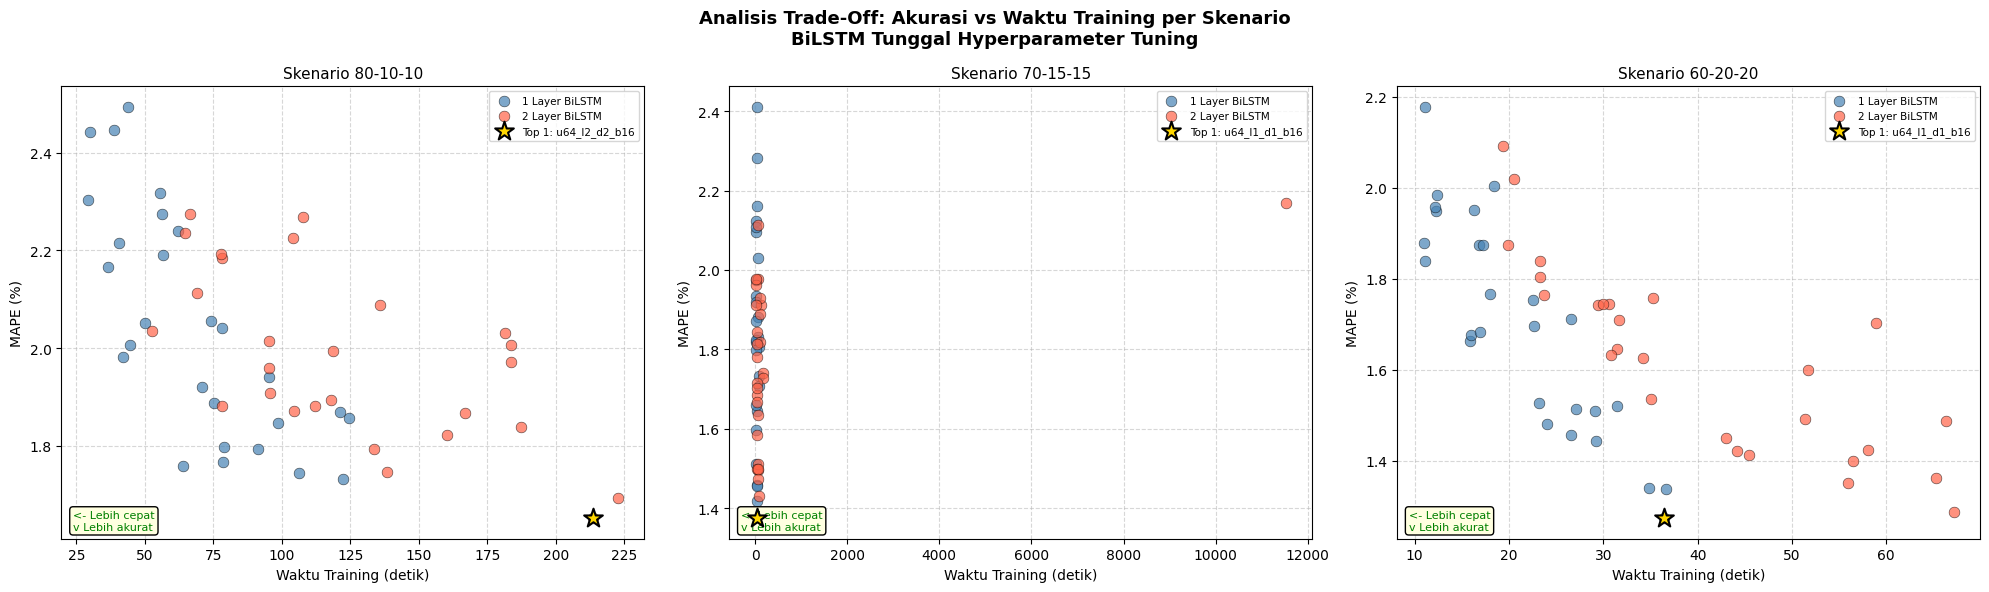

✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'


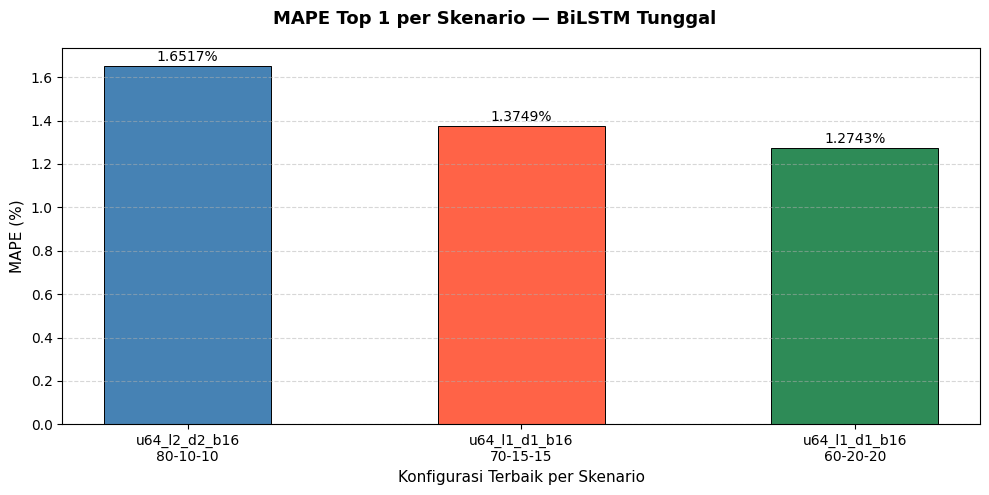

✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training per Skenario\n'
    'BiLSTM Tunggal Hyperparameter Tuning',
    fontsize=13, fontweight='bold'
)

colors_layer = {1: 'steelblue', 2: 'tomato'}

for col_idx, nama_skenario in enumerate(skenario_list):
    ax     = axes[col_idx]
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = top1_per_skenario[nama_skenario]

    for n_layer in [1, 2]:
        s = subset[subset['Layer BiLSTM'] == n_layer]
        ax.scatter(
            s['Waktu (detik)'], s['MAPE (%)'],
            c=colors_layer[n_layer],
            label=f'{n_layer} Layer BiLSTM',
            s=60, edgecolors='black', linewidths=0.4, alpha=0.7, zorder=3
        )

    # Highlight top 1
    ax.scatter(
        [top1['Waktu (detik)']], [top1['MAPE (%)']],
        c='gold', s=200, edgecolors='black',
        linewidths=1.5, zorder=5, marker='*',
        label=f"Top 1: {top1['Nama']}"
    )

    ax.set_title(f'Skenario {nama_skenario}', fontsize=11)
    ax.set_xlabel('Waktu Training (detik)', fontsize=10)
    ax.set_ylabel('MAPE (%)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(
        '<- Lebih cepat\nv Lebih akurat',
        xy=(0.02, 0.02), xycoords='axes fraction',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )

plt.tight_layout()
plt.savefig('tradeoff_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'")

# Bar chart top 1 per skenario
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('MAPE Top 1 per Skenario — BiLSTM Tunggal', fontsize=13, fontweight='bold')

nama_list = [top1_per_skenario[s]['Nama'] + '\n' + s for s in skenario_list]
mape_list = [top1_per_skenario[s]['MAPE (%)'] for s in skenario_list]
bars      = ax.bar(nama_list, mape_list, color=['steelblue', 'tomato', 'seagreen'],
                   edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, mape_list):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_xlabel('Konfigurasi Terbaik per Skenario', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top1_per_skenario.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'")


## CELL 9 — Loss Curve (Training vs Validation)

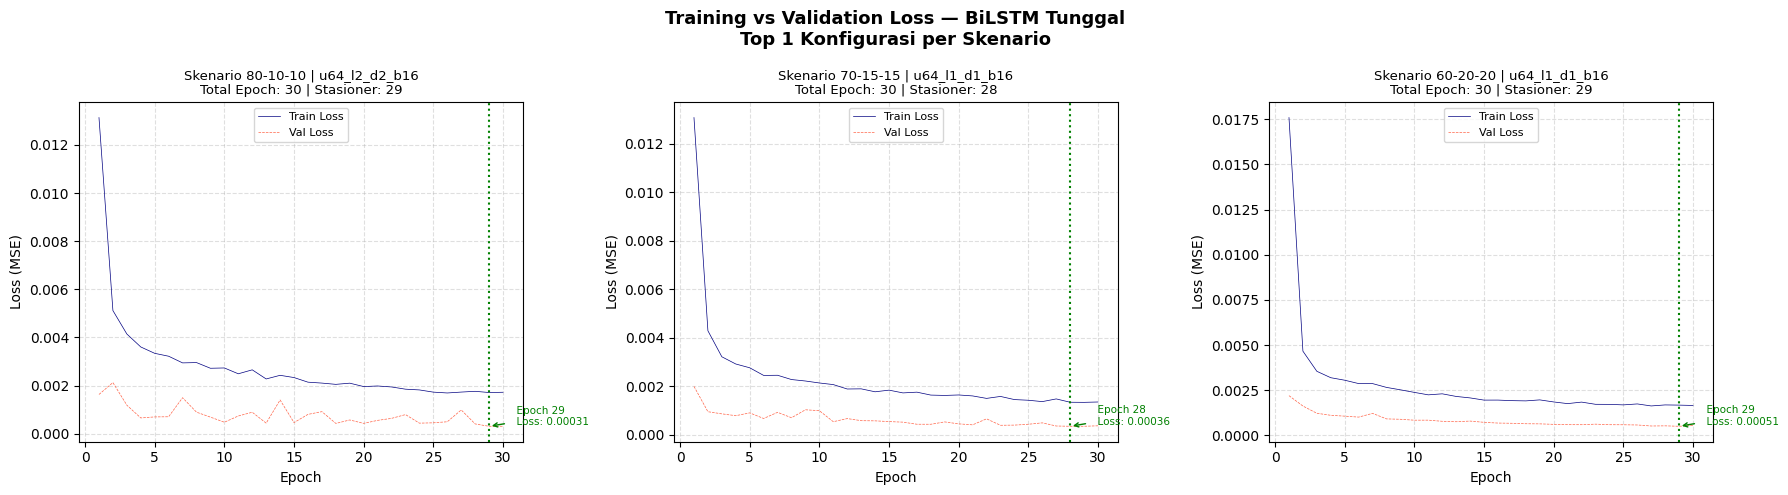

✅ Loss curve disimpan ke: loss_curve_BiLSTM.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Training vs Validation Loss \u2014 BiLSTM Tunggal\n'
    f'Top 1 Konfigurasi per Skenario',
    fontsize=13, fontweight='bold'
)

for col_idx, nama_skenario in enumerate(skenario_final):
    top1_nama = top1_per_skenario[nama_skenario]['Nama']
    key = f'{top1_nama}_{nama_skenario}'
    ax  = axes[col_idx]
    h   = history_tuning[key]

    total_epoch   = len(h['loss'])
    val_loss_arr  = np.array(h['val_loss'])
    best_epoch    = int(np.argmin(val_loss_arr)) + 1
    best_val_loss = val_loss_arr[best_epoch - 1]

    ax.plot(range(1, total_epoch + 1), h['loss'],
            label='Train Loss', color='navy', linewidth=0.5)
    ax.plot(range(1, total_epoch + 1), h['val_loss'],
            label='Val Loss', color='tomato',
            linewidth=0.5, linestyle='--')

    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
        fontsize=7.5, color='green',
        arrowprops=dict(arrowstyle='->', color='green', lw=1)
    )

    ax.set_title(
        f'Skenario {nama_skenario} | {top1_nama}\n'
        f'Total Epoch: {total_epoch} | Stasioner: {best_epoch}',
        fontsize=9.5
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Loss curve disimpan ke: loss_curve_BiLSTM.png')


## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

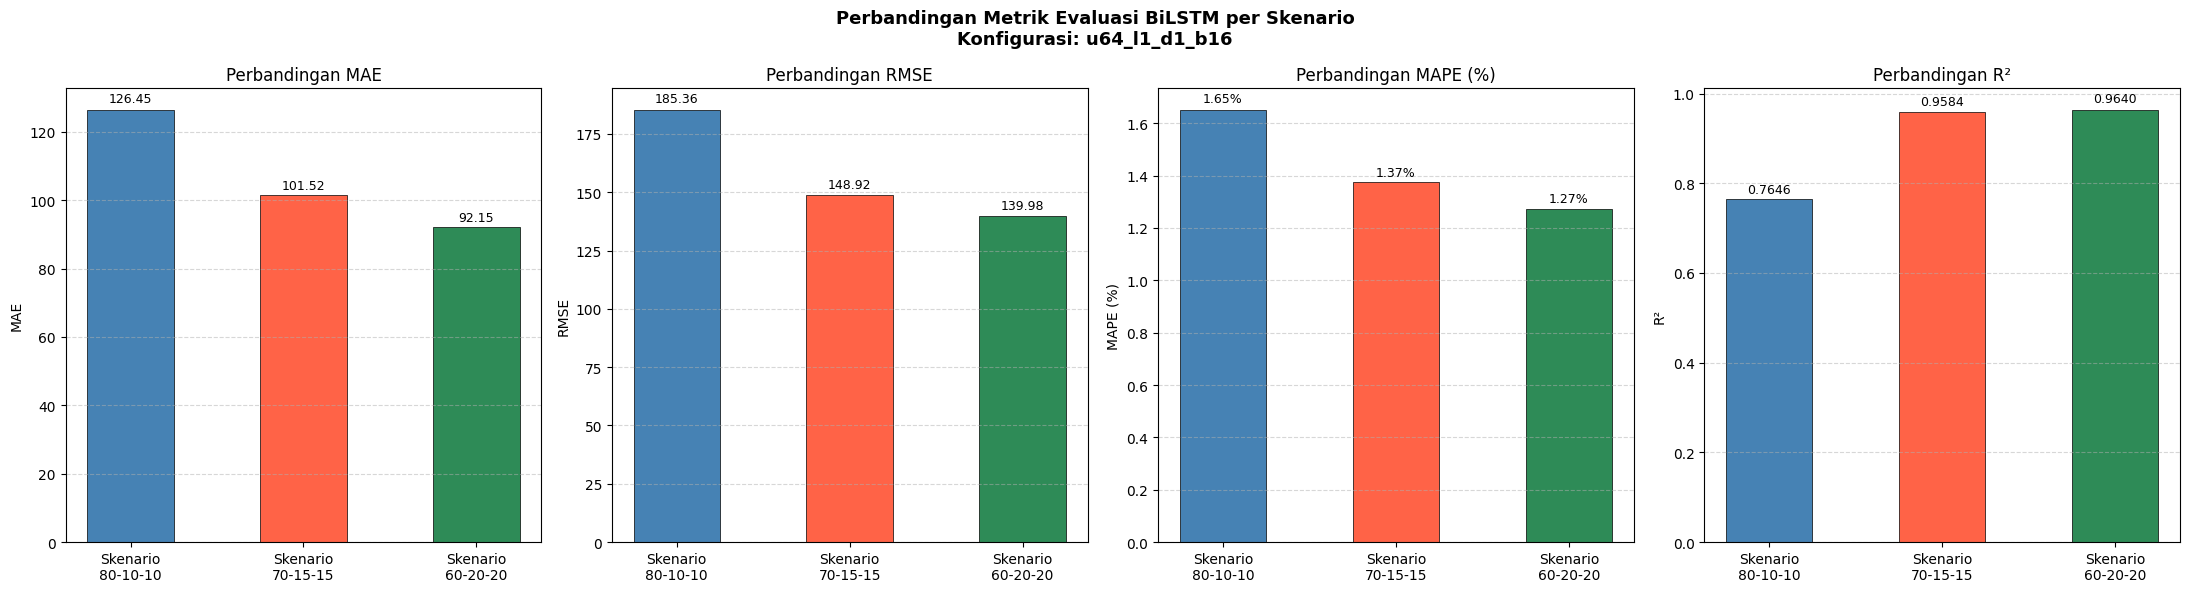


🏆 Performa terbaik BiLSTM:
   Skenario      : 60-20-20
   MAE           : 92.15
   RMSE          : 139.98
   MAPE          : 1.2743%
   R²            : 0.9640
   Waktu Training: 36.46 detik


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    f'Perbandingan Metrik Evaluasi BiLSTM per Skenario\n'
    f'Konfigurasi: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
bar_colors   = ['steelblue', 'tomato', 'seagreen']

# Pastikan urutan skenario konsisten
df_plot = df_final_hasil.set_index('Skenario').loc[skenario_final].reset_index()

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax   = axes[i]
    vals = df_plot[metrik].values

    bars = ax.bar(
        [f'Skenario\n{s}' for s in skenario_final],
        vals, color=bar_colors,
        edgecolor='black', linewidth=0.5, width=0.5
    )

    for bar, val in zip(bars, vals):
        if metrik == 'MAPE (%)':
            txt = f'{val:.2f}%'
        elif metrik == 'R2':
            txt = f'{val:.4f}'
        else:
            txt = f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f"\n🏆 Performa terbaik BiLSTM:")
print(f"   Skenario      : {best_row['Skenario']}")
print(f"   MAE           : {best_row['MAE']:.2f}")
print(f"   RMSE          : {best_row['RMSE']:.2f}")
print(f"   MAPE          : {best_row['MAPE (%)']}%")
print(f"   R²            : {best_row['R2']:.4f}")
print(f"   Waktu Training: {best_row['Waktu (detik)']} detik")

## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.


Model terbaik: u64_l1_d1_b16_60-20-20
MAE: 92.15 | RMSE: 139.98 | MAPE: 1.2743% | R²: 0.9640


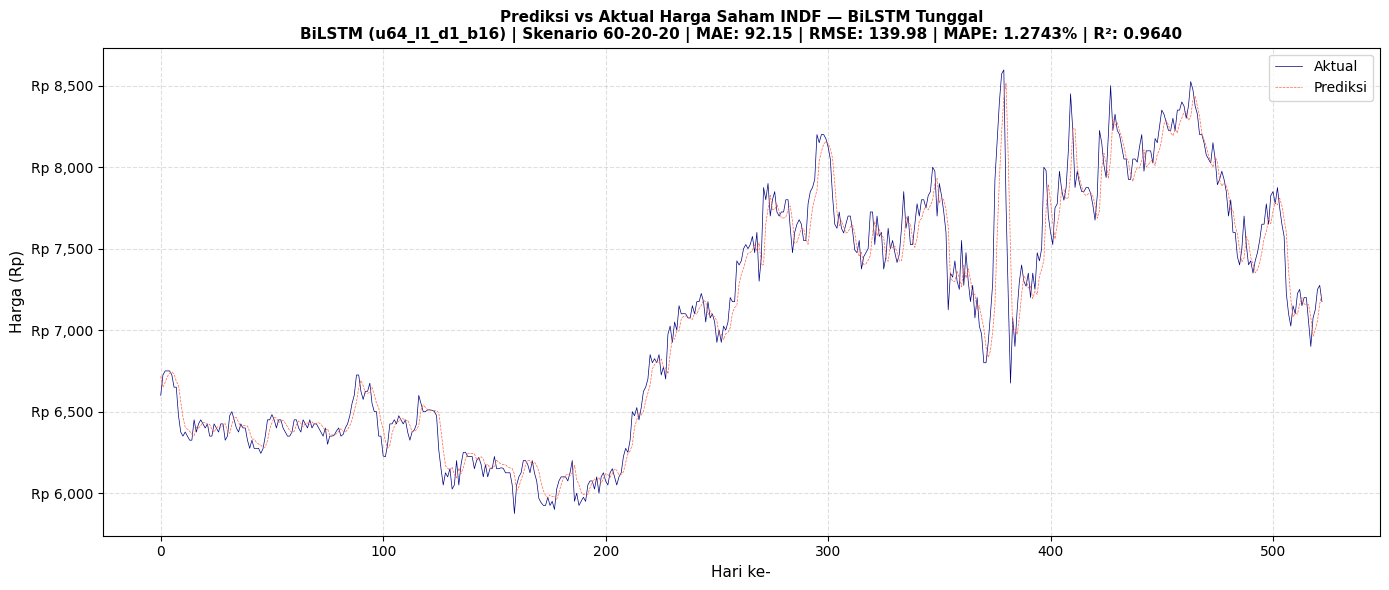

✅ Grafik prediksi vs aktual disimpan ke: 'prediksi_vs_aktual_terbaik_BiLSTM.png'


In [9]:
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = f"BiLSTM ({best_row['Konfigurasi']})"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_waktu    = best_row['Waktu (detik)']

print(f"\nModel terbaik: {best_key}")
print(f"MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f}")

data = datasets[best_skenario]

y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)
y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_true, label='Aktual', color='navy', linewidth=0.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=0.5, linestyle='--')
ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF — BiLSTM Tunggal\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi vs aktual disimpan ke: 'prediksi_vs_aktual_terbaik_BiLSTM.png'")

## CELL 13 — Prediksi 1 Hari & 30 Hari ke Depan

Kedua prediksi dijalankan dalam 1 cell menggunakan strategi **recursive forecasting**:
- Loop 30 iterasi, iterasi pertama = prediksi 1 hari (23 Oktober 2025)
- Setiap hasil prediksi dianggap aktual dan dimasukkan ke window berikutnya
- Output: prediksi 1 hari + tabel & grafik prediksi 30 hari



  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN
  Model            : u64_l1_d1_b16_60-20-20
  Data terakhir    : 22 October 2025 | Harga: Rp 7,175
  Tanggal prediksi : 23 October 2025
  Prediksi Harga   : Rp 7,195.86
  Selisih          : Rp 20.86 (naik)

  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN
  Mulai   : 23 October 2025
  Selesai : 03 December 2025
         Tanggal  Prediksi (Rp)
 23 October 2025    7195.859863
 24 October 2025    7183.759766
 27 October 2025    7171.459961
 28 October 2025    7160.399902
 29 October 2025    7150.009766
 30 October 2025    7140.750000
 31 October 2025    7130.520020
03 November 2025    7120.080078
04 November 2025    7109.200195
05 November 2025    7097.330078
06 November 2025    7085.899902
07 November 2025    7074.680176
10 November 2025    7063.950195
11 November 2025    7054.580078
12 November 2025    7044.839844
13 November 2025    7034.890137
14 November 2025    7024.189941
17 November 2025    7013.890137
18 November 2025    7003.189941
19

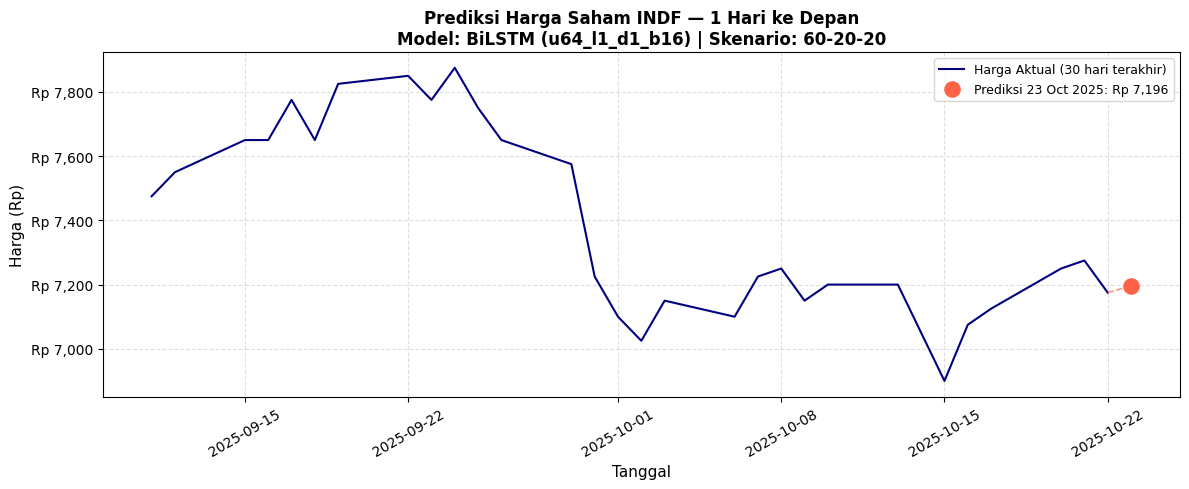

✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_BiLSTM.png'


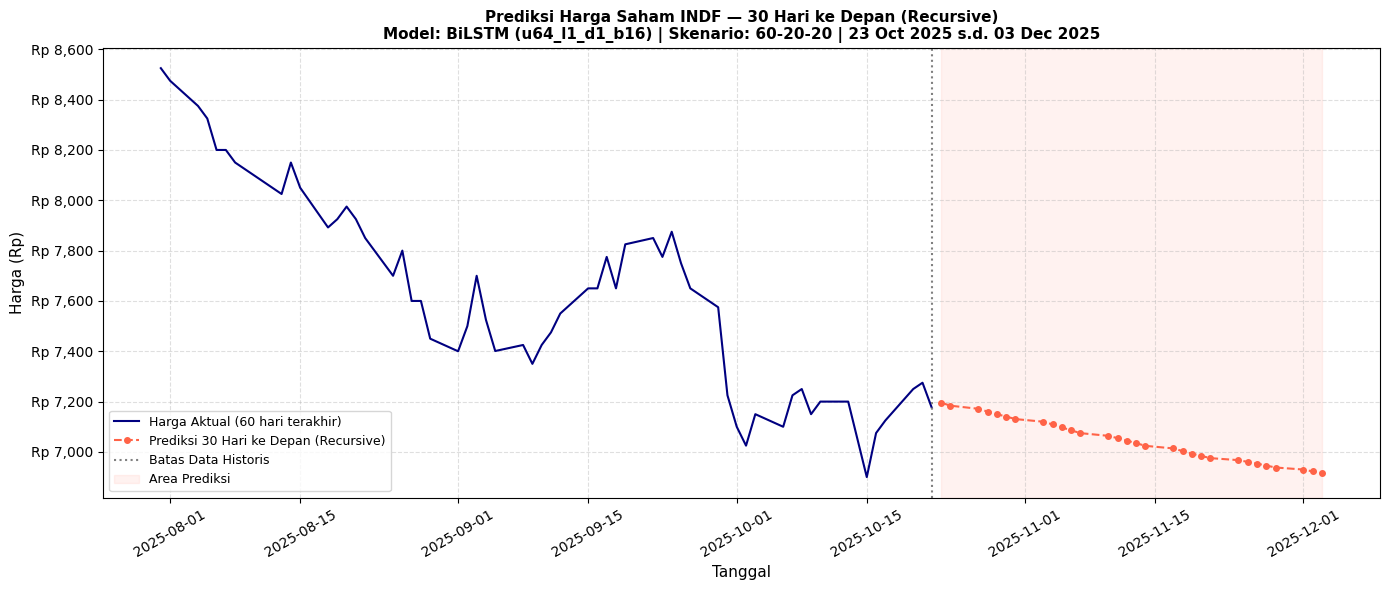

✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_BiLSTM.png'


In [10]:
model_terbaik      = model_final[best_key]
scaler_terbaik     = datasets[best_skenario]['scaler']
data_close_full    = df[['Close']].values
last_window_raw    = data_close_full[-WINDOW_SIZE:]
last_window_scaled = scaler_terbaik.transform(last_window_raw)
tanggal_terakhir   = df.index[-1]

DAYS_AHEAD     = 30
current_window = last_window_scaled.copy()
prediksi_list  = []

for hari in range(DAYS_AHEAD):
    X_input = current_window.reshape(1, WINDOW_SIZE, 1)
    pred    = model_terbaik.predict(X_input, verbose=0)[0][0]
    prediksi_list.append(pred)
    new_point      = np.array([[pred]])
    current_window = np.concatenate([current_window[1:], new_point], axis=0)

prediksi_scaled_arr = np.array(prediksi_list).reshape(-1, 1)
prediksi_rupiah_arr = scaler_terbaik.inverse_transform(prediksi_scaled_arr).flatten()

tanggal_awal = tanggal_terakhir + pd.offsets.BDay(1)
tanggal_pred = pd.date_range(start=tanggal_awal, periods=DAYS_AHEAD, freq='B')

# Output 1 hari
pred_1hari     = prediksi_rupiah_arr[0]
tanggal_1hari  = tanggal_pred[0]
harga_terakhir = data_close_full[-1][0]
selisih        = pred_1hari - harga_terakhir
arah           = "naik" if selisih >= 0 else "turun"

print("\n" + "=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN")
print("=" * 55)
print(f"  Model            : {best_key}")
print(f"  Data terakhir    : {tanggal_terakhir.strftime('%d %B %Y')} "
      f"| Harga: Rp {harga_terakhir:,.0f}")
print(f"  Tanggal prediksi : {tanggal_1hari.strftime('%d %B %Y')}")
print(f"  Prediksi Harga   : Rp {pred_1hari:,.2f}")
print(f"  Selisih          : Rp {abs(selisih):,.2f} ({arah})")
print("=" * 55)

# Output 30 hari
df_prediksi_30 = pd.DataFrame({
    'Tanggal'       : tanggal_pred.strftime('%d %B %Y'),
    'Prediksi (Rp)' : prediksi_rupiah_arr.round(2)
})
print("\n" + "=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN")
print("=" * 55)
print(f"  Mulai   : {tanggal_pred[0].strftime('%d %B %Y')}")
print(f"  Selesai : {tanggal_pred[-1].strftime('%d %B %Y')}")
print("=" * 55)
print(df_prediksi_30.to_string(index=False))
df_prediksi_30.to_csv('prediksi_30hari_BiLSTM.csv', index=False)
print("\n✅ Hasil disimpan ke: 'prediksi_30hari_BiLSTM.csv'")

# Grafik 1 hari
fig, ax = plt.subplots(figsize=(12, 5))
tanggal_hist = df.index[-WINDOW_SIZE:]
harga_hist   = data_close_full[-WINDOW_SIZE:].flatten()
ax.plot(tanggal_hist, harga_hist, label='Harga Aktual (30 hari terakhir)',
        color='navy', linewidth=1.5)
label_1hari = f"Prediksi {tanggal_1hari.strftime('%d %b %Y')}: Rp {pred_1hari:,.0f}"
ax.scatter([tanggal_1hari], [pred_1hari], color='tomato', s=120, zorder=5, label=label_1hari)
ax.plot([tanggal_hist[-1], tanggal_1hari], [harga_hist[-1], pred_1hari],
        color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_title(
    f'Prediksi Harga Saham INDF — 1 Hari ke Depan\n'
    f'Model: {best_label} | Skenario: {best_skenario}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_1hari_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_BiLSTM.png'")

# Grafik 30 hari
LOOKBACK_VIS     = 60
tanggal_hist_vis = df.index[-LOOKBACK_VIS:]
harga_hist_vis   = data_close_full[-LOOKBACK_VIS:].flatten()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tanggal_hist_vis, harga_hist_vis, label='Harga Aktual (60 hari terakhir)',
        color='navy', linewidth=1.5)
ax.plot(tanggal_pred, prediksi_rupiah_arr,
        label='Prediksi 30 Hari ke Depan (Recursive)',
        color='tomato', linewidth=1.5, linestyle='--', marker='o', markersize=4)
ax.axvline(x=tanggal_terakhir, color='gray', linestyle=':', linewidth=1.5,
           label='Batas Data Historis')
ax.axvspan(tanggal_pred[0], tanggal_pred[-1], alpha=0.08, color='tomato',
           label='Area Prediksi')
tgl_mulai   = tanggal_pred[0].strftime('%d %b %Y')
tgl_selesai = tanggal_pred[-1].strftime('%d %b %Y')
ax.set_title(
    f'Prediksi Harga Saham INDF — 30 Hari ke Depan (Recursive)\n'
    f'Model: {best_label} | Skenario: {best_skenario} | '
    f'{tgl_mulai} s.d. {tgl_selesai}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_30hari_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_BiLSTM.png'")